<a href="https://colab.research.google.com/github/Aisaule-wonder/5-Day-Gen-AI-Intensive-Kaggle-Course-with-Google-/blob/main/%D0%9E%D0%A3_MT_seq2seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Машинный перевод

Семинар основан на материалах [NLP курса](https://github.com/yandexdataschool/nlp_course/tree/2022/resources).

Сегодня мы напишем автокодировщик и применим его к задаче машинного перевода.


![img](https://esciencegroup.files.wordpress.com/2016/03/seq2seq.jpg)
_(img: esciencegroup.files.wordpress.com)_


Автокодировщики способны конвертировать что угодно в любой другой объект, что применимо к задачам:
 * Машинного перевода и разговорным диалоговым системам
 * [Генерация подписей к картинкам](http://mscoco.org/dataset/#captions-challenge2015) и [image2latex задача](https://openai.com/requests-for-research/#im2latex) (сверточный кодировщик, рекуррентный декодировщик)
 * Генерация [картинок по подписям](https://arxiv.org/abs/1511.02793) (рекуррентный кодировщик, сверточный декодировщик)
 * Grapheme2phoneme - конвертация слов в их транскрипции

### Наша задача: машинный перевод

Мы протестируем автокодировочные модели на задаче машинного перевода с русского на английский язык. Конкретнее, мы будем переводить описания отелей и хостелов. Эта задача с одной стороны покажет сложность машинного перевода, но с другой стороны не потребует от вас провести недели за обучением моделей (если под рукой нет свободного GPU).

Прежде чем приступить к архитектуре требуется предобработать данные. ~~Начнем с токенизации~~ Ок, в этот раз мы сделали предобработку за вас. Как обычно в подобных задачах, данные были разбиты на токены с помощью WordPunctTokenizer.

Однако это не все. Объекты обучающей выборки содержат редкие уникальные слова. Поэтому, если мы будем работать на уровне слов, то придется иметь дело со словарем достаточно большого размера. Если же мы перейдем на символьный уровень, то потребуется гораздо больше итераций алгоритма, чтобы сойтись. В нашем случае стоит выбрать вариант посередине.

Один из наиболее популярных подходов называется [Byte Pair Encoding](https://github.com/rsennrich/subword-nmt) aka __BPE__. Алгоритм начинается с токенизации на уровне символов, а затем итеративно объединяет наиболее часто встречающиеся пары для N итерации. В итоге часто встречающиеся слова объединяются в один токен, а редкие слова разбиваются на отдельные части или даже символы.

In [ ]:
# !pip3 install torch>=1.3.0
!pip3 install subword-nmt &> log
!wget https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1 -O data.txt
!wget https://raw.githubusercontent.com/yandexdataschool/nlp_course/2020/week04_seq2seq/vocab.py -O vocab.py

--2025-04-28 16:49:46--  https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6017:18::a27d:212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/mw8tdyetqboqwkn5ma886/data.txt?rlkey=t9fmsizx27ikh0vak0ir265a6&dl=1 [following]
--2025-04-28 16:49:47--  https://www.dropbox.com/scl/fi/mw8tdyetqboqwkn5ma886/data.txt?rlkey=t9fmsizx27ikh0vak0ir265a6&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uccaf13ff4520ab7f781ffc3360a.dl.dropboxusercontent.com/cd/0/inline/CorAxHSAOuKEOpN4cmOkjY7hRkdB3vjCvMtYRHCBaUGQRgwCbedeR0bX5BCK9bzhhp-0zI1N2wSjs2F3r_UoK266KSy5Y_cIORziYvsTTvVlXMTko4jKHlVypFMI5jnL3Iw/file?dl=1# [following]
--2025-04-28 16:49:47--  https://uccaf13ff4520ab7f781ffc3360a.dl.dropboxusercontent.com/cd/0/inline/CorAxHSAOuKEOp

In [ ]:
from nltk.tokenize import WordPunctTokenizer
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE
tokenizer = WordPunctTokenizer()

def tokenize(x):
    return ' '.join(tokenizer.tokenize(x.lower()))

# сплит и токенизация данных
with open('train.en', 'w') as f_src,  open('train.ru', 'w') as f_dst:
    for line in open('data.txt'):
        src_line, dst_line = line.strip().split('\t')
        f_src.write(tokenize(src_line) + '\n')
        f_dst.write(tokenize(dst_line) + '\n')

# создание BPE словаря и его применение к данным
bpe = {}
for lang in ['en', 'ru']:
    learn_bpe(open('./train.' + lang), open('bpe_rules.' + lang, 'w'), num_symbols=8000)
    bpe[lang] = BPE(open('./bpe_rules.' + lang))

    with open('train.bpe.' + lang, 'w') as f_out:
        for line in open('train.' + lang):
            f_out.write(bpe[lang].process_line(line.strip()) + '\n')

100%|██████████| 8000/8000 [00:09<00:00, 859.28it/s] 


### Создание словарей

Теперь мы построим словари, которые свяжут строки с ID токенов и наоборот. Эти словари потребуются на этапе обучения моделей, а также на этапе конвертации выходов моделей назад в слова.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [ ]:
data_inp = np.array(open('./train.bpe.ru').read().split('\n'))
data_out = np.array(open('./train.bpe.en').read().split('\n'))

from sklearn.model_selection import train_test_split
train_inp, dev_inp, train_out, dev_out = train_test_split(data_inp, data_out, test_size=3000,
                                                          random_state=42)
for i in range(3):
    print('inp:', train_inp[i])
    print('out:', train_out[i], end='\n\n')

inp: на территории обустроена бесплатная частная парковка .
out: free private parking is available on site .

inp: кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .
out: guests can find many bars and restaurants within a 5 - minute walk .

inp: отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .
out: hotel san miguel is located in central more@@ lia , 750 metres from the city ’ s main square and cathedral .



In [ ]:
from vocab import Vocab
inp_voc = Vocab.from_lines(train_inp)
out_voc = Vocab.from_lines(train_out)

In [ ]:
# Так работает перевод строк в ID и обратно
batch_lines = sorted(train_inp, key=len)[5:10]
batch_ids = inp_voc.to_matrix(batch_lines)
batch_lines_restored = inp_voc.to_lines(batch_ids)

print("lines")
print(batch_lines)
print("\nwords to ids (0 = bos, 1 = eos):")
print(batch_ids)
print("\nback to words")
print(batch_lines_restored)

lines
['гостевой дом r .', 'до афин — 20 км .', 'работает боулинг .', 'оборудован балкон .', 'подключен wi - fi .']

words to ids (0 = bos, 1 = eos):
tensor([[   0, 2688, 2943, 1108,   29,    1,    1,    1],
        [   0, 2922, 1834, 8035,   59, 3800,   29,    1],
        [   0, 6030, 2083,   29,    1,    1,    1,    1],
        [   0, 4927, 1870,   29,    1,    1,    1,    1],
        [   0, 5549, 1453,   27,  592,   29,    1,    1]])

back to words
['гостевой дом r .', 'до афин — 20 км .', 'работает боулинг .', 'оборудован балкон .', 'подключен wi - fi .']


Нарисуем распределения длин строк входных данных (на русском) и уже переведенных - таргета (на английском), чтобы оценить объем задачи.

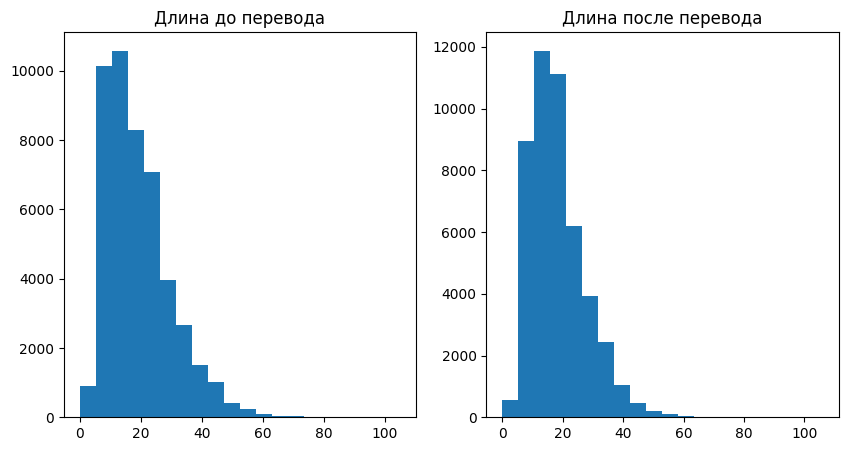

In [ ]:
plt.figure(figsize=[10, 5])
plt.subplot(1, 2, 1)
plt.title("Длина до перевода")
plt.hist(list(map(len, map(str.split, train_inp))), bins=20);

plt.subplot(1, 2, 2)
plt.title("Длина после перевода")
plt.hist(list(map(len, map(str.split, train_out))), bins=20);

### Encoder-Decoder

Код ниже пример реализации простого автокодировщика: один GRU энкодер/декодер, без механизма внимания и других слоев.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

def set_random_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_random_seed(1)

cuda


In [ ]:
class BasicModel(nn.Module):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128):
        """
        Простой автокодировщик для задачи seq2seq
        """
        super().__init__() # инициализация базового класса для создания слоев, обучающих параметров и т.п.

        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size
        self.emb_size = emb_size

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)

        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def forward(self, inp, out):
        """ Применение модели к данным на этапе обучения """
        initial_state = self.encode(inp)
        return self.decode(initial_state, out)


    def encode(self, inp, **flags):
        """
        Принимает на вход символьную последовательность, вычисляет начальное состояние
        :param inp: матрица входных токенов [batch, time]
        :returns: тензоры начального состояние декодера (один или несколько)
        """
        inp_emb = self.emb_inp(inp)
        batch_size = inp.shape[0]

        enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)
        # enc_seq: [batch, time, hid_size], last_state: [batch, hid_size]

        # замечание: last_state на самом деле не последнее состояние, так как в последовательностях используется padding
        # выведем реальный last_state
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]

        dec_start = self.dec_start(last_state)
        return [dec_start]

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Принимает предыдущее состояние декодера и токены, возвращает новое состояние и логиты для следующих токенов
        :param prev_state: массив (list) тензоров предыдущих состояний декодера, аналогичный возвращаемому encoder(...)
        :param prev_tokens: выходные токены предыдущей итерации, целочисленный вектор [batch_size]
        :return: массив (list) тензоров следующих состояний декодера, тензор с логитами [batch, len(out_voc)]
        """
        prev_gru0_state = prev_state[0]

        prev_emb = self.emb_out(prev_tokens)
        new_dec_state = self.dec0(prev_emb, prev_gru0_state)

        output_logits = F.softmax(self.logits(new_dec_state), dim=-1)
        output_logits = torch.log(output_logits + 1e-9)

        return [new_dec_state], output_logits

    def decode(self, initial_state, out_tokens, **flags):
        """ Итерирование по референсным токенам (выходным) с шагом декодера """
        batch_size = out_tokens.shape[0]
        state = initial_state

        # начальные логиты: всегда предсказывают токен BOS
        onehot_bos = F.one_hot(torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64),
                               num_classes=len(self.out_voc)).to(device=out_tokens.device)
        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)

        logits_sequence = [first_logits]
        for i in range(out_tokens.shape[1] - 1):
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)
        return torch.stack(logits_sequence, dim=1)

    def decode_inference(self, initial_state, max_len=100, **flags):
        """ Генерация переводов моделью (жадная версия алгоритма) """
        batch_size, device = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64,
                              device=device)]
        all_states = [initial_state]

        for i in range(max_len):
            state, logits = self.decode_step(state, outputs[-1])
            outputs.append(logits.argmax(dim=-1))
            all_states.append(state)
        return torch.stack(outputs, dim=1), all_states

    def translate_lines(self, inp_lines, **kwargs):
        inp = self.inp_voc.to_matrix(inp_lines).to(device)
        initial_state = self.encode(inp)
        out_ids, states = self.decode_inference(initial_state, **kwargs)
        return self.out_voc.to_lines(out_ids.cpu().numpy()), states


In [ ]:
# проверим себя
model = BasicModel(inp_voc, out_voc).to(device)

dummy_inp_tokens = inp_voc.to_matrix(sorted(train_inp, key=len)[5:10]).to(device)
dummy_out_tokens = out_voc.to_matrix(sorted(train_out, key=len)[5:10]).to(device)

h0 = model.encode(dummy_inp_tokens)
h1, logits1 = model.decode_step(h0, torch.arange(len(dummy_inp_tokens), device=device))

assert isinstance(h1, list) and len(h1) == len(h0)
assert h1[0].shape == h0[0].shape and not torch.allclose(h1[0], h0[0])
assert logits1.shape == (len(dummy_inp_tokens), len(out_voc))

logits_seq = model.decode(h0, dummy_out_tokens)
assert logits_seq.shape == (dummy_out_tokens.shape[0], dummy_out_tokens.shape[1], len(out_voc))

# полный проход
logits_seq2 = model(dummy_inp_tokens, dummy_out_tokens)
assert logits_seq2.shape == logits_seq.shape

In [ ]:
dummy_translations, dummy_states = model.translate_lines(train_inp[:3], max_len=25)
print("Перевод необученной моделью:")
print('\n'.join([line for line in dummy_translations]))

Перевод необученной моделью:
ío с@@ green@@ oaks rijeka infrared breakfasts ef ef fashion chateau bla@@ belgian flooring esco flooring esco ri suite beira stan@@ pat@@ cagliari ented cha@@
separate leu@@ bian pamukkale tar ío с@@ waters champ@@ delicacies por@@ 850 cop@@ tech@@ peace lingen culture iva protec@@ visiting zag@@ cher mobile experience ń
separate leu@@ bian pamukkale tar ío с@@ waters champ@@ delicacies por@@ 850 cop@@ tech@@ peace lingen culture iva protec@@ visiting zag@@ cher mobile experience ń


### Cross-entropy loss

Функцию посчета лосса для нашей задачи можно выразить следующим образом:
$$ L = {\frac1{|D|}} \sum_{X, Y \in D} \sum_{y_t \in Y} - \log p(y_t \mid y_1, \dots, y_{t-1}, X, \theta) $$

где $|D|$ означает __суммарную длину всех последовательностей__, включая токен BOS и первый токен EOS, за исключением токенов PAD.

In [ ]:

def compute_loss(model, inp, out, **flags):
    """
    Считает лосс (float32 scalar) по формуле выше
    :param inp: входная матрица токенов, int32[batch, time]
    :param out: референсная (таргет) матрица токенов, int32[batch, time]

    Чтобы пройти тесты, ваша функция должна
    * включать в подсчет лосса первое вхождение токена EOS, но не последующие для одной последовательности
    * делить сумму лоссов на сумму длин входных последовательностей (используйте voc.compute_mask)
    """
    # compute a boolean mask that equals "1" until first EOS (including that EOS)
    mask = model.out_voc.compute_mask(out) # [batch_size, out_len]
    targets_1hot = F.one_hot(out, len(model.out_voc)).to(torch.float32) # [batch_size, out_len, num_tokens]

    # выходы модели, [batch_size, out_len, num_tokens]
    logits_seq = model(inp, out)

    # логарифмы вероятностей для всех токенов на всех шагах, [batch_size, out_len, num_tokens]
    # вычислены на предыдущем шаге - выходы модели - логарифмы

    # логарифмы вероятностей правильных выходов модели, [batch_size, out_len]
    logp_out = (logits_seq * targets_1hot).sum(dim=-1)
    # ^-- этот код выбирает вероятности для реального следующего токена (следующий токен из таргета)
    # Замечание: более эффективно можно посчитать лосс, используя F.cross_entropy

    # усредненная кросс-энтропия по токенам, где mask == True
    return -logp_out[mask].mean() # усредненный лосс, scalar

In [ ]:
dummy_loss = compute_loss(model, dummy_inp_tokens, dummy_out_tokens)
print("Loss:", dummy_loss)
assert np.allclose(dummy_loss.item(), 7.5, rtol=0.1, atol=0.1), "We're sorry for your loss"

# test autograd
dummy_loss.backward()
for name, param in model.named_parameters():
    assert param.grad is not None and abs(param.grad.max()) != 0, f"Param {name} received no gradients"

Loss: tensor(7.5017, device='cuda:0', grad_fn=<NegBackward0>)


### Оценка качества машинного перевода: BLEU

Машинный перевод часто оценивают с помощью [BLEU](https://en.wikipedia.org/wiki/BLEU) скора. Эта метрика вычисляет, какая часть предсказанных n-грамм действительно встречается в референсном переводе. Вычисление работает для n=1,2,3 и 4, вычисляя среднее геометрическое со штрафом, если перевод короче референса.

Несмотря на [многочисленные недостатки](http://www.cs.jhu.edu/~ccb/publications/re-evaluating-the-role-of-bleu-in-mt-research.pdf) BLEU, это все еще одна из наиболее часто используемых метрик, которая также является одной из простейших для вычисления.

In [ ]:
from nltk.translate.bleu_score import corpus_bleu
import math

def compute_bleu(model, inp_lines, out_lines, bpe_sep='@@ ', batch_size=512, **flags):
    """
    Вычисляет BLEU скор модели (на уровне корпусов текстов) по входным данным и референсному переводу
    Замечание: для более аккуратного подсчета BLEU и сравнения результатов стоит использовать https://pypi.org/project/sacrebleu
    """
    n_batches = math.ceil(len(inp_lines) / batch_size)

    with torch.no_grad():
        translations = []

        for i in range(n_batches):
            inp_lines_i = inp_lines[i * batch_size : (i + 1) * batch_size]
            translations_i, _ = model.translate_lines(inp_lines_i, **flags)
            translations_i = [line.replace(bpe_sep, '') for line in translations_i]
            translations.extend(translations_i)

        actual = [line.replace(bpe_sep, '') for line in out_lines]
        return corpus_bleu(
            [[ref.split()] for ref in actual],
            [trans.split() for trans in translations],
            smoothing_function=lambda precisions, **kw: [p + 1.0 / p.denominator for p in precisions]
            ) * 100

In [ ]:
compute_bleu(model, dev_inp, dev_out)

0.002538569958965743

### Training loop

Обучение автокодировщиков мало чем отличается от обучения других видов нейронных сетей: те же батчи, подсчет лосса, обратный проход и обновление весов

In [ ]:
from IPython.display import clear_output
from tqdm import tqdm, trange
metrics = {'train_loss': [], 'dev_bleu': [] }

model = BasicModel(inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32

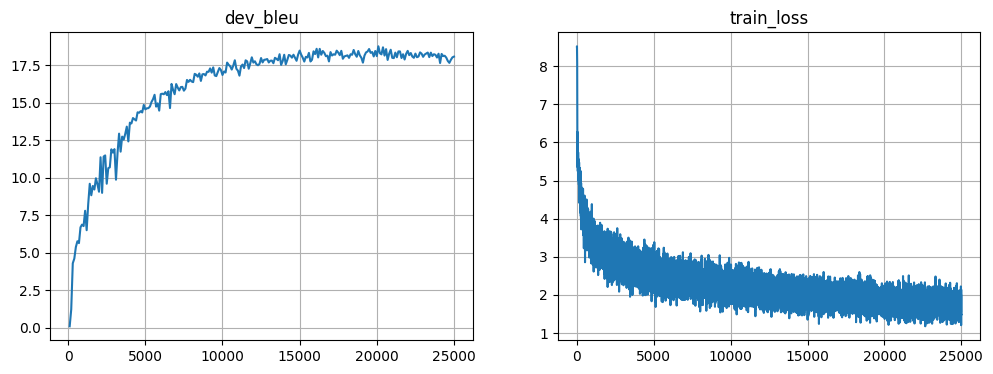

Mean loss=1.694


100%|██████████| 25000/25000 [24:46<00:00, 16.82it/s]


In [ ]:
for _ in trange(25000):
    step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    loss_t = compute_loss(model, batch_inp, batch_out)
    loss_t.backward()
    opt.step()
    opt.zero_grad()

    metrics['train_loss'].append((step, loss_t.item()))

    if step % 100 == 0:
        metrics['dev_bleu'].append((step, compute_bleu(model, dev_inp, dev_out)))

        clear_output(True)
        plt.figure(figsize=(12,4))
        for i, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), i + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

# Замечание: колебания BLEU на графике вполне нормальны до тех пор пока в среднем в долгосрочной перспективе (например, 5к шагов или батчей) есть положительные изменения

In [ ]:
assert np.mean(metrics['dev_bleu'][-10:], axis=0)[1] > 15, "Нужно больше BLEU, еще больше"

In [ ]:
for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в распоряжении гостей общая кухня и общая гостиная .
you will find a shared kitchen at the shared kitchen .

кроме того , предоставляется прокат велосипедов , услуги трансфера и бесплатная парковка .
the property offers free parking and bicycle rental .

расстояние до города ки@@ сси@@ м@@ ми составляет 26 км .
the unit is 13 km from the property .

апартаменты в пент@@ хаусе с общим открытым бассейном , садом , кондиционером и террасой для загара расположены в 5 минутах ходьбы от пляжа на курорте ка@@ бо - рой .
offering a garden with a pool , a garden , barbecue and sun terrace , apartments at the copacabana beach is a self - catering accommodation located in the centre of split .

апартаменты mo@@ s@@ co@@ w point - loft red square находятся в москве , в 200 метрах от большого театра .
apartment in li@@ cin@@ min@@ ble 200 is 200 metres from the old town district .

в вашем распоряжении собственная ванная комната с душем и полотенцами .
featuring a shower , private bathrooms also co

## Bonus: attention mechanism

### Your Attention Required

В данной секции мы хотим, чтобы вы улучшили базовую модель, добавив в нее реализацию механизма внимания.

Задание разделено на две части: создание слоя __механизма внимания__ и применение его в __seq2seq модели с механизмом внимания__.

### Attention

Здесь вам нужно реализовать слой, который подсчитывает поростые аттеншены сложением:

На вход подается последовательность кодировщика $ h^e_0, h^e_1, h^e_2, ..., h^e_T$ и единственный вектор состояния декодировщика $h^d$,

* Подсчет логитов двухслойной полносвязной нейросетью
$$a_t = linear_{out}(tanh(linear_{e}(h^e_t) + linear_{d}(h_d)))$$
* Получаем вероятности из логитов
$$ p_t = {{e ^ {a_t}} \over { \sum_\tau e^{a_\tau} }} $$

* Добавляем состояния кодировщика к вероятностям, чтобы получить __выход аттеншена (attention response)__
$$ attn = \sum_t p_t \cdot h^e_t $$

Вы можете узнать больше о механизме внимания из [данной лекции](https://distill.pub/2016/augmented-rnns/).

In [ ]:
class AttentionLayer(nn.Module):
    def __init__(self, name, enc_size, dec_size, hid_size, activ=torch.tanh):
        """ Слой, подсчитывающий выходы аттеншена и веса """
        super().__init__()
        self.name = name
        self.enc_size = enc_size # размер вектора состояния кодировщика
        self.dec_size = dec_size # размер вектора состояния декодировщика
        self.hid_size = hid_size # размер вектора скрытого состояния аттеншена
        self.activ = activ       # функция активации (нелинейность) в аттеншене

        # создаем обучаемые параметры:
        self.w_e = torch.nn.parameter.Parameter(torch.rand(enc_size, hid_size), requires_grad=True)
        self.w_d = torch.nn.parameter.Parameter(torch.rand(dec_size, hid_size), requires_grad=True)
        self.w_out = torch.nn.parameter.Parameter(torch.rand(hid_size, 1), requires_grad=True)


    def forward(self, enc, dec, inp_mask):
        """
        Подсчитывает выход аттеншена и веса
        :param enc: входная последовательность кодировщика, float32[batch_size, ninp, enc_size]
        :param dec: выходная последовательность декодировщика (query), float32[batch_size, dec_size]
        :param inp_mask: маска для последовательностей кодировщика (0 после первого токена eos), float32 [batch_size, ninp]
        :returns: attn[batch_size, enc_size], probs[batch_size, ninp]
            - attn - вектор выхода аттеншена (взвешенная сумма enc)
            - probs - веса аттеншена после софтмакса (softmax)
        """

        batch_size = enc.shape[0]

        # так как вектор декодировщика один, а входных много, добавим размерность в тензор для бродкастинга
        dec = dec[:, None, :]

        # Подсчет логитов
        a_t = self.activ(enc @ self.w_e + dec @ self.w_d) @ self.w_out

        # Наложение маски - если mask равна 0, логиты должны быть -inf или -1e9
        # Вам может понадобиться torch.where
        a_t[~inp_mask] = -torch.inf
        a_t = a_t.squeeze(dim=-1)

        # Подсчет вероятностей аттеншена (softmax)
        probs = F.softmax(a_t, dim=-1)

        # Подсчет выхода аттеншена, используя enc и probs
        attn = (probs[:, :, None] * enc).sum(dim=1)

        return attn, probs

### Seq2seq модель с механизмом внимания

Теперь вы можете использовать аттеншен слой в построении модели. Простейший способ использования этого слоя - применение его на этапе декодировки.


На каждом шагу алгоритма используем __предыдущее__ состояние декодировщика, чтобы получить выход аттеншена. Затем подадим этот выход на вход следующем аттеншен слою.

Ключейвой деталью имплементации модели является __тензор состояния модели__. Говоря простым языком, вы можете добавить любые тензоры к массиву выходов энкодера. Доступны они будут на каждом шаге декодера. В тензор состояния модели могут входить:
* Скрытые состояния с последнего слоя RNN (как это реализовано в базовой модели выше)
* Полная последовательность выходов энкодера и маски
* Вероятности, выдаваемые слоями аттеншена (например, для визуализации)

_Также существуют и другие способы, как можно внедрить механизм внимания в архитектуру нейронной сети, а также существуют различные виды аттеншен слоев. Для более детального изучения данной тематики рекомендуем [эту статью](https://arxiv.org/abs/1609.08144), [и эту](https://arxiv.org/abs/1706.03762), и [еще вот эту](https://arxiv.org/abs/1808.03867) для вдохновения. Также для погружения в способы решения задач image captioning/im2latex можно почитать [эту статью про visual attention](https://arxiv.org/abs/1502.03044)_

In [ ]:
class AttentiveModel(BasicModel):
    def __init__(self, name, inp_voc, out_voc,
                 emb_size=64, hid_size=128, attn_size=32):
        """ Модель машинного перевода с использованием механизма внимания (описание модели дано выше) """
        super().__init__(inp_voc, out_voc, emb_size, hid_size) # инициализация базового класса для создания слоев, обучающих параметров и т.п.

#        self.inp_voc, self.out_voc = inp_voc, out_voc
#        self.hid_size = hid_size

        self.attn = AttentionLayer('attn_layer', hid_size, hid_size, attn_size)
        self.dec0 = nn.GRUCell(emb_size + hid_size, hid_size)


    def encode(self, inp, **flags):
        """
        Принимает на вход символьную последовательность, считает начальное состояние
        :param inp: матрица входных токенов [batch, time]
        :return: массив тензоров начальных состояний декодера
        """

        # кодирование входной последовательности и создание начального состояния для декодеровщика
        inp_emb = self.emb_inp(inp)
        enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        dec_start = self.dec_start(last_state)
        zero_start = torch.zeros_like(dec_start)

        # применение слоя аттеншен к начальному состоянию декодеровщика
        inp_mask = self.inp_voc.compute_mask(inp)
        first_attn, attn_probs = self.attn(enc_seq, zero_start, inp_mask)

        # Создаем первый тензор состояния, включающий:
        # * начальные состояния для декодеровщика
        # * закодированную последовательность и аттеншен маску для нее
        # * последним элементом тензора должны идти вероятности из аттеншена

        first_state = [zero_start, enc_seq, inp_mask, attn_probs]
        return first_state


    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Принимает на вход предыдущее состояние декодеровщика, возвращает новое его состояние и логиты для следующих токенов
        :param prev_state: массив тензоров предыдущих состояний декодера
        :param prev_tokens: предыдущие токены из выхода слоя, целочисленный вектор [batch_size]
        :return: массив тензоров следующего состояния декодера, тензор логитов [batch, n_tokens]
        """

        dec_hidden, enc_seq, inp_mask, _ = prev_state

        attn_dec, attn_probs = self.attn(enc_seq, dec_hidden, inp_mask)

        prev_emb = self.emb_out(prev_tokens).view(-1, self.emb_size)

        dec_in = torch.concat([prev_emb, attn_dec], dim=-1)
        new_dec_hidden = self.dec0(dec_in, dec_hidden)

        output_logits = F.softmax(self.logits(new_dec_hidden), dim=-1)
        output_logits = torch.log(output_logits)

        new_dec_state = [new_dec_hidden, enc_seq, inp_mask, attn_probs]
        return new_dec_state, output_logits

### Обучение модели с attention
Для обучения используйте ранее написанную инфраструктуру для базовой модели.

In [ ]:
set_random_seed(1)
model_attn = AttentiveModel('attentive', inp_voc, out_voc).to(device)
dummy_translations, dummy_states = model_attn.translate_lines(train_inp[:3], max_len=25)
print("Перевод необученной моделью:")
print('\n'.join([line for line in dummy_translations]))

In [ ]:
metrics = {'train_loss': [], 'dev_bleu': [] }

lr = 1e-3
batch_size = 32

opt = torch.optim.Adam(model_attn.parameters(), lr=lr)

for _ in trange(25000):
    model_attn.train()
    step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    loss_t = compute_loss(model_attn, batch_inp, batch_out)
    loss_t.backward()
    opt.step()
    opt.zero_grad()

    metrics['train_loss'].append((step, loss_t.item()))

    if step % 100 == 0:
        with torch.no_grad():
            metrics['dev_bleu'].append((step, compute_bleu(model_attn, dev_inp, dev_out)))

            clear_output(True)
            plt.figure(figsize=(12,4))
            for i, (name, history) in enumerate(sorted(metrics.items())):
                plt.subplot(1, len(metrics), i + 1)
                plt.title(name)
                plt.plot(*zip(*history))
                plt.grid()
            plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)


In [ ]:
for inp_line, trans_line in zip(dev_inp[::500], model_attn.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

In [ ]:
compute_bleu(model_attn, dev_inp, dev_out)

### Визуализация весов модели

После обучения модели с механизмом внимания вы можете проверить то, насколько модель рационально назначила веса, визуализировав их.

Мы написали для вас функцию, которая визуализирует веса аттеншена, опираясь на [`Bokeh`](https://bokeh.pydata.org/en/latest/index.html).

__Замечание:__ вовсе не обязательно визуализировать только указанным способом. Если вы хотите визуализировать методом, отличным от Bokeh, то делайте)

In [ ]:
import bokeh.plotting as pl
import bokeh.models as bm
from bokeh.io import output_notebook, show
output_notebook()

def draw_attention(inp_line, translation, probs):
    """ Функция для визуализации весов аттеншена """
    inp_tokens = inp_voc.tokenize(inp_line)
    trans_tokens = out_voc.tokenize(translation)
    probs = probs[:len(trans_tokens), :len(inp_tokens)]

    fig = pl.figure(x_range=(0, len(inp_tokens)), y_range=(0, len(trans_tokens)),
                    x_axis_type=None, y_axis_type=None, tools=[])
    fig.image([probs[::-1]], 0, 0, len(inp_tokens), len(trans_tokens))

    fig.add_layout(bm.LinearAxis(axis_label='source tokens'), 'above')
    fig.xaxis.ticker = np.arange(len(inp_tokens)) + 0.5
    fig.xaxis.major_label_overrides = dict(zip(np.arange(len(inp_tokens)) + 0.5, inp_tokens))
    fig.xaxis.major_label_orientation = 45

    fig.add_layout(bm.LinearAxis(axis_label='translation tokens'), 'left')
    fig.yaxis.ticker = np.arange(len(trans_tokens)) + 0.5
    fig.yaxis.major_label_overrides = dict(zip(np.arange(len(trans_tokens)) + 0.5, trans_tokens[::-1]))

    show(fig)

In [ ]:
inp = dev_inp[::500]

trans, states = model_attn.translate_lines(inp)

# возьмите тензор вероятностей аттеншена из тензора состояния модели (в вашей кастомной модели порядок и конфигурация могу быть другими)
# тензор вероятностей должен иметь форму[batch_size, translation_length, input_length]
# например, если эти вероятности находятся в конце каждого тензора состояния, можно использовать np.stack([state[-1] for state in states], axis=1)
attention_probs = np.stack([state[-1].cpu().detach().numpy() for state in states], axis=1)

In [ ]:
for i in range(5):
    draw_attention(inp[i], trans[i], attention_probs[i])

# Выглядит уже лучше?

## Super Bonus! Let's dive deeper!

Давайте попробуем найти лучшую модель для данного задания. Используем все, что сможете найти.

* различные вариации рекуррентных слоев: RNN, GRU, LSTM, другие архитектуры
* двухсторонние (bidirectional) архитектуры кодировщика, различные виды и реализации аттеншена (additive, dot-product, multi-head)
* дропаут для слов, обучающие сценарии, шедулеры
* замена жадного алгоритма на этапе инференса beam search'ем


Попробуем заменить жадный алгоритм на beam search. Модель остается такой же, меняется только метод decode_inference. На каждой итерации кодирования будем брать несколько наиболее вероятных последовательностей. В конце выберем из них наиболее вероятную.


Такой подход дал более качественный перевод, хотя вычислительно и по памяти это более затратно.

In [ ]:
class AttentiveBSModel(AttentiveModel):

    def __init__(self, name, inp_voc, out_voc, n_beams,
                 emb_size=64, hid_size=128, attn_size=32):

        super().__init__(name, inp_voc, out_voc)
        self.n_beams = n_beams



    def decode_inference(self, initial_state, max_len=100, **flags):
            """ Генерация переводов моделью beam search """
            batch_size, device = len(initial_state[0]), initial_state[0].device

            # будем сохранять стейты, id токенов на выходе модели и накопленное значение логитов последовательности

            # заполнение начала строки
            state = initial_state
            outputs = [torch.full([batch_size, self.n_beams], self.out_voc.bos_ix, dtype=torch.int64,
                                  device=device)]
            probs = torch.full([batch_size, self.n_beams], 0, dtype=torch.float64, device=device)

            # заполнение первого слова
            first_state, first_output = self.decode_step(initial_state, outputs[-1][:, 0])
            most_prob_outputs = first_output.argsort(dim=-1, descending=True)[:, :self.n_beams]
            assert most_prob_outputs.shape == (batch_size, self.n_beams)

            prev_outputs = [outputs[-1]]
            outputs.append(most_prob_outputs)
            probs += torch.take_along_dim(first_output, most_prob_outputs, dim=-1)
            assert probs.shape == (batch_size, self.n_beams)

            all_states = [initial_state, [first_state for _ in range(self.n_beams)]]
            states_nums = [torch.full([batch_size, self.n_beams], 0, dtype=torch.int64, device=device)]

            # заполнение остальных слов
            for i in range(1, max_len):
                outputs_bm = []
                probs_bm = []
                states_bm = []
                prev_outputs_bm = []

                for bm in range(self.n_beams):
                    prev_output = outputs[-1][:, bm].view(-1, 1)
                    assert prev_output.shape == (batch_size, 1)

                    # prev_state у каждого объекта свой, нужно пройтись циклом по всем n_beams возможных
                    # prev_state и записать их выходы согласно индексам
                    prev_states_list = all_states[-1]
                    # стейты, которые будут заполняться в цикле ниже
                    prev_state = [torch.zeros_like(elem) for elem in first_state]

                    for i_pst in range(self.n_beams):
                        idx = (states_nums[-1][:, bm] == i_pst)
                        if idx.sum() > 0:
                            for n_elem in range(len(prev_state)):
                                prev_state[n_elem][idx] = prev_states_list[i_pst][n_elem][idx]

                    # для каждого bm получаем новый state и логиты
                    state_bm, logits_bm = self.decode_step(prev_state, prev_output)
                    states_bm.append(state_bm)

                    # берем наиболее вероятные n_beams логитов
                    most_prob_outputs = logits_bm.argsort(dim=-1, descending=True)[:, :self.n_beams]
                    assert most_prob_outputs.shape == (batch_size, self.n_beams)

                    outputs_bm.append(most_prob_outputs)

                    # вычисляем новый логит (log(p_t * p_(t-1)) = log(p_t) + log(p_(t-1)))
                    assert probs[:, bm].view(-1, 1).shape == (batch_size, 1)
                    curr_probs = probs[:, bm].view(-1, 1) + torch.take_along_dim(logits_bm,
                                                                                 most_prob_outputs,
                                                                                 dim=-1)

                    assert curr_probs.shape == (batch_size, self.n_beams)
                    probs_bm.append(curr_probs)

                    prev_outputs_bm.append(prev_output.view(-1, 1).expand(-1, self.n_beams))
                    assert prev_outputs_bm[-1].shape == (batch_size, self.n_beams)


                assert len(outputs_bm) == self.n_beams
                assert len(probs_bm) == self.n_beams
                assert len(states_bm) == self.n_beams

                # приведем листы outputs и probs к размеру [batch_size, n_beams ** 2]
                outputs_bm = torch.flatten(torch.stack(outputs_bm, dim=1), start_dim=1)
                probs_bm = torch.flatten(torch.stack(probs_bm, dim=1), start_dim=1)
                prev_outputs_bm = torch.flatten(torch.stack(prev_outputs_bm, dim=1), start_dim=1)
                assert outputs_bm.shape == (batch_size, self.n_beams ** 2)
                assert probs_bm.shape == (batch_size, self.n_beams ** 2)
                assert prev_outputs_bm.shape == (batch_size, self.n_beams ** 2)

                # среди всех n_beams ** 2 логитов находим наиболее вероятные n_beams штук и записываем в outputs
                high_prob_beams = probs_bm.argsort(dim=-1, descending=True)[:, :self.n_beams]
                high_prob_outputs = (torch.take_along_dim(outputs_bm, high_prob_beams, dim=-1))
                outputs.append(high_prob_outputs)
                assert outputs[-1].shape == (batch_size, self.n_beams)
                prev_outputs.append(torch.take_along_dim(prev_outputs_bm, high_prob_beams, dim=-1))

                # обновляем накопленные логиты
                probs = torch.take_along_dim(probs_bm, high_prob_beams, dim=-1)
                assert probs.shape == (batch_size, self.n_beams)

                # выясним, в каких beams были максимальные накопленные логиты
                # и сохраним соответсвующие state и prev_outputs
                high_prob_beam_nums = torch.div(high_prob_beams, self.n_beams, rounding_mode="floor")
                assert high_prob_beam_nums.shape == (batch_size, self.n_beams)
                states_nums.append(high_prob_beam_nums)
                all_states.append(states_bm)
                assert len(all_states[-1]) == self.n_beams
                assert len(all_states[-1][0]) == len(initial_state)


            # выбираем последовательность, имеющую наибольшую вероятность
            max_prob = probs.argmax(dim=-1, keepdim=True)
            assert max_prob.shape == (batch_size, 1)

            # разматываем последовательность к началу,
            # сопоставляя наиболее вероятные токены и соответсвующие им предыдущие
            most_prob_seq = []
            while len(prev_outputs) > 0:
                curr_output = outputs.pop()
                most_prob_seq = [torch.take_along_dim(curr_output, max_prob, dim=-1)] + most_prob_seq
                curr_prev = prev_outputs.pop()
                prev = torch.take_along_dim(curr_prev, max_prob, dim=-1)
                max_prob = (outputs[-1] == prev).int().argmax(dim=-1, keepdim=True)

            return torch.stack(most_prob_seq, dim=1), all_states



    def translate_lines(self, inp_lines, **kwargs):
        inp = self.inp_voc.to_matrix(inp_lines).to(device)
        initial_state = self.encode(inp)
        out_ids, state = self.decode_inference(initial_state, **kwargs)
        out_lines = self.out_voc.to_lines(out_ids)

        return out_lines, state[-1]

In [ ]:
set_random_seed(1)
model_attn_bs = AttentiveBSModel('attentive_bs', inp_voc, out_voc, n_beams=4).to(device)
dummy_translations, dummy_states = model_attn_bs.translate_lines(train_inp[:3], max_len=25)
print("Перевод необученной моделью:")
print('\n'.join([line for line in dummy_translations[:3]]))



In [ ]:
set_random_seed(1)
model_attn_bs = AttentiveBSModel('attentive_bs', inp_voc, out_voc, n_beams=4).to(device)
metrics = {'train_loss': [], 'dev_bleu': [] }

lr = 1e-3
batch_size = 32

opt = torch.optim.Adam(model_attn_bs.parameters(), lr=lr)

for _ in trange(25000):
    model_attn_bs.train()
    step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    loss_t = compute_loss(model_attn_bs, batch_inp, batch_out)
    loss_t.backward()
    opt.step()
    opt.zero_grad()

    metrics['train_loss'].append((step, loss_t.item()))

    if step % 500 == 0:
        with torch.no_grad():
            metrics['dev_bleu'].append((step, compute_bleu(model_attn_bs, dev_inp, dev_out,
                                                           batch_size=64)))

            clear_output(True)
            plt.figure(figsize=(12,4))
            for i, (name, history) in enumerate(sorted(metrics.items())):
                plt.subplot(1, len(metrics), i + 1)
                plt.title(name)
                plt.plot(*zip(*history))
                plt.grid()
            plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

In [ ]:
print("bleu", metrics["dev_bleu"][-1])

In [ ]:
for inp_line, trans_line in zip(dev_inp[::500], model_attn_bs.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

__Дополнительная "необязательная" домашка.__ Реализуйте какую-либо архитектуру руками. Простой импорт модели с последующим фит-предиктом не подойдет. Не требуется писать BERT "с нуля". Достаточно будет реализовать более простую модель (например, VAE). Оцениваться такая модель будет в зависимости от сложности архитектуры, а также полученного скора BLEU на тестовых данных.

Альтернативно можно не писать арзитектуру "с нуля", но требуется показать улучшение скора BLEU за счет нестрандартных методов работы с готовыми моделями. Стандарнтым методом в данном контексте считается импорт модели, ее обучени и предикт на тесте. Попробуйте, например достать эмбеддинги из претрейн трансформера и поработать с ними отдельно. Как вариант, можно определенным образом взвесить эмбеддинги слов предложения для получения осмысленного эмбеддинга всей фразы. Далее можно поверх получившихся эмбеддингов обучить уже другую модель.

Если вы реализовали один из указанных вариантов, то выполнение обязательной части будет автоматически зачитано.

Напишите небольшой отчет о ваших экспериментах, обоснуйте выбор модели или необычной стратегии обучения, сделайте выводы.

In [ ]:
# <here could've been your code>

`[ваш отчет об экспериментах, логи, все, что угодно]`